# Hull Tactical Market Prediction

> **Kaggle Competition**: [Hull Tactical Market Prediction](https://www.kaggle.com/competitions/hull-tactical-market-prediction)
>
> This notebook predicts S&P 500 daily excess returns and turns them into portfolio weights in [0, 2]. The objective is to maximize the competition's adjusted Sharpe ratio, which penalizes excess volatility and sustained underperformance relative to the market index.
>
> **Key results**: adjusted Sharpe **0.8605** on the final temporal holdout (1,500 days, 200-day purge gap), compared with the baseline (weight = 1.0) score of **0.7151**.

> **Assessment data rule**: the workflow uses only `data/train.csv`; Kaggle `test.csv` is excluded because it has no target.

## Workflow

1. Load libraries, plotting style, and fixed ex-ante constants.
2. Define the competition score and utility functions used across the notebook.
3. Load data and create the strict outer split: tuning block, purge gap, and final holdout.
4. Build engineered features with a train-only fit and leakage-safe transform.
5. Inspect engineered features with intermediate tables and diagnostic plots.
6. Fit the regime detector (Gaussian HMM, 3 states), train the return model (XGBoost with confidence intervals), and define the strategy sizing logic.
7. Build the inner walk-forward CV cache on the tuning block and define the CV evaluation function.
8. Run an Optuna strategy-only search on cached CV folds and inspect study results.
9. Refit the pipeline on the full tuning block, evaluate once on the untouched holdout, and build performance series.
10. Report selected strategy parameters, best inner CV score, final holdout score, and holdout plots.


In [1]:
# 1. Load libraries, plotting style, and fixed ex-ante constants.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from hmmlearn.hmm import GaussianHMM
HAS_XGBOOST = True
HAS_HMMLEARN = True

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "font.size": 11,
        "legend.frameon": False,
    }
)
COLORS = {
    "blue": "#1f4e79",
    "teal": "#2a9d8f",
    "gold": "#e9c46a",
    "red": "#d62828",
    "gray": "#6c757d",
}
optuna.logging.set_verbosity(optuna.logging.WARNING)

TARGET_COLUMNS = ["forward_returns", "risk_free_rate", "market_forward_excess_returns"]
LAGGED_TARGET_COLUMNS = [
    "lagged_forward_returns",
    "lagged_risk_free_rate",
    "lagged_market_forward_excess_returns",
]
VIX_COLUMNS = [f"V{i}" for i in range(1, 14)]
REGIME_MULTIPLIERS = {
    "bull_low_vol": 1.30,
    "bear_high_vol": 0.50,
    "transition": 0.70,
    "normal": 1.00,
}

FEATURE_PARAMS = {
    "rolling_windows": (5, 20, 60, 252),
    "rolling_sharpe_windows": (20, 60),
    "rolling_autocorr_windows": (5, 20),
    "availability_threshold": 0.5,
    "history_buffer": 400,
    "min_periods": 5,
    "clip_feature_value": 10.0,
    "vix_rf_estimators": 300,
    "vix_random_state": 42,
}

# Fixed ex-ante modeling parameters for this notebook.
MODEL_PARAMS = {
    "random_state": 42,
    "model_type": "xgboost",
    "n_estimators": 400,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_samples_leaf": 20,
}

FIXED_STRATEGY_DEFAULTS = {
    "min_weight": 0.0,
    "max_weight": 2.0,
    "vol_scale_min": 0.5,
    "vol_scale_max": 2.0,
    "vol_servo_window": 60,
    "hard_vol_cap": 1.20,
}
INITIAL_STRATEGY_PARAMS = {
    "confidence_threshold": 0.55,
    "gain": 80.0,
    "target_annual_vol": 0.16,
    "soft_vol_cap": 1.10,
    **FIXED_STRATEGY_DEFAULTS,
}
SEARCH_SPACE = {
    "confidence_threshold": (0.35, 0.75),
    "gain": (20.0, 180.0),
    "target_annual_vol": (0.08, 0.30),
    "soft_vol_cap": (1.00, 1.20),
}

TRAIN_PATH = Path("data/train.csv")
OUTER_HOLDOUT_SIZE = 1500
OUTER_PURGE_GAP = 200
N_OPTUNA_TRIALS = 40

print(f"HAS_XGBOOST = {HAS_XGBOOST}")
print(f"HAS_HMMLEARN = {HAS_HMMLEARN}")
print(f"Optuna version = {optuna.__version__}")


HAS_XGBOOST = True
HAS_HMMLEARN = True
Optuna version = 4.8.0


In [2]:
# 2. Define the competition score and the small utility functions used across the notebook.
# Compute the competition's adjusted Sharpe score for a proposed weight series.
def score(solution: pd.DataFrame, submission: pd.DataFrame) -> float:
    if not pd.api.types.is_numeric_dtype(submission["prediction"]):
        raise ValueError("Predictions must be numeric")

    solution = solution.copy()
    solution["position"] = submission["prediction"].to_numpy()

    if solution["position"].max() > 2:
        raise ValueError(f"Position of {solution['position'].max()} exceeds maximum of 2")
    if solution["position"].min() < 0:
        raise ValueError(f"Position of {solution['position'].min()} below minimum of 0")

    solution["strategy_returns"] = (
        solution["risk_free_rate"] * (1 - solution["position"]) + solution["position"] * solution["forward_returns"]
    )

    strategy_excess_returns = solution["strategy_returns"] - solution["risk_free_rate"]
    strategy_excess_cumulative = (1 + strategy_excess_returns).prod()
    strategy_mean_excess_return = strategy_excess_cumulative ** (1 / len(solution)) - 1
    strategy_std = solution["strategy_returns"].std()
    if strategy_std == 0:
        raise ValueError("Division by zero, strategy std is zero")

    sharpe = strategy_mean_excess_return / strategy_std * np.sqrt(252)
    strategy_volatility = float(strategy_std * np.sqrt(252) * 100)

    market_excess_returns = solution["forward_returns"] - solution["risk_free_rate"]
    market_excess_cumulative = (1 + market_excess_returns).prod()
    market_mean_excess_return = market_excess_cumulative ** (1 / len(solution)) - 1
    market_std = solution["forward_returns"].std()
    market_volatility = float(market_std * np.sqrt(252) * 100)
    if market_volatility == 0:
        raise ValueError("Division by zero, market std is zero")

    excess_vol = max(0, strategy_volatility / market_volatility - 1.2)
    vol_penalty = 1 + excess_vol

    return_gap_penalty = max(0, (market_mean_excess_return - strategy_mean_excess_return) * 100 * 252)
    return_penalty = 1 + (return_gap_penalty ** 2) / 100

    adjusted_sharpe = sharpe / (vol_penalty * return_penalty)
    return min(float(adjusted_sharpe), 1_000_000)


# Sort prefixed feature names by their alphabetic prefix and numeric suffix.
def key_num(name: str) -> tuple[str, int]:
    digits = "".join(c for c in name if c.isdigit())
    return name[0], int(digits) if digits else 0


# Calculate a stable lag-1 autocorrelation, returning zero when variance is degenerate.
def autocorr(values: np.ndarray) -> float:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 3:
        return 0.0
    a, b = x[:-1], x[1:]
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


# Yield expanding-window train/validation indices with a purge gap before each validation block.
def walk_forward_splits(n_samples: int, n_splits: int, initial_train_size: int, validation_size: int, purge_gap: int):
    for i in range(n_splits):
        train_end = initial_train_size + i * validation_size
        val_start = train_end + purge_gap
        val_end = val_start + validation_size
        if val_end > n_samples:
            break
        yield np.arange(0, train_end), np.arange(val_start, val_end)


Split summary


total_rows               8990
tuning_rows              7290
outer_purge_gap_rows      200
holdout_rows             1500
tuning_end_date_id       7289
holdout_start_date_id    7490
dtype: int64

Inner CV parameters


n_splits                 6
initial_train_size    3645
validation_size        583
purge_gap              145
dtype: int64

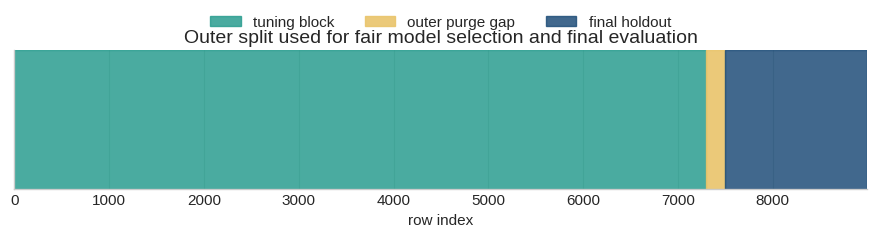

In [3]:
# 3. Load data/train.csv and create the strict outer split.
train_df = pd.read_csv(TRAIN_PATH)

n_rows = len(train_df)
if OUTER_HOLDOUT_SIZE + OUTER_PURGE_GAP >= n_rows:
    raise ValueError("OUTER_HOLDOUT_SIZE + OUTER_PURGE_GAP is too large for dataset length.")

split_idx = n_rows - OUTER_HOLDOUT_SIZE - OUTER_PURGE_GAP
tune_df = train_df.iloc[:split_idx].copy()
holdout_df = train_df.iloc[split_idx + OUTER_PURGE_GAP :].copy()

cv_params = {
    "n_splits": 6,
    "initial_train_size": max(1500, int(len(tune_df) * 0.5)),
    "validation_size": max(150, int(len(tune_df) * 0.08)),
    "purge_gap": min(150, max(60, int(len(tune_df) * 0.02))),
}

split_summary = pd.Series(
    {
        "total_rows": int(n_rows),
        "tuning_rows": int(len(tune_df)),
        "outer_purge_gap_rows": int(OUTER_PURGE_GAP),
        "holdout_rows": int(len(holdout_df)),
        "tuning_end_date_id": int(tune_df["date_id"].iloc[-1]),
        "holdout_start_date_id": int(holdout_df["date_id"].iloc[0]),
    }
)

print("Split summary")
display(split_summary)
print("Inner CV parameters")
display(pd.Series(cv_params))

fig, ax = plt.subplots(figsize=(11, 1.8))
ax.axvspan(0, len(tune_df), color=COLORS["teal"], alpha=0.85, label="tuning block")
ax.axvspan(len(tune_df), len(tune_df) + OUTER_PURGE_GAP, color=COLORS["gold"], alpha=0.9, label="outer purge gap")
ax.axvspan(len(tune_df) + OUTER_PURGE_GAP, n_rows, color=COLORS["blue"], alpha=0.85, label="final holdout")
ax.set_xlim(0, n_rows)
ax.set_yticks([])
ax.set_xlabel("row index")
ax.set_title("Outer split used for fair model selection and final evaluation")
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.35))
plt.show()


In [4]:
# 4. Build the engineered features with a train-only fit and a leakage-safe transform.
# Add lagged target columns when the source file does not already provide them.
def ensure_lagged_targets(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    mapping = {
        "lagged_forward_returns": "forward_returns",
        "lagged_risk_free_rate": "risk_free_rate",
        "lagged_market_forward_excess_returns": "market_forward_excess_returns",
    }
    for lag_col, source_col in mapping.items():
        if lag_col not in df.columns and source_col in df.columns:
            df[lag_col] = df[source_col].shift(1)
    return df


# Fit train-only feature metadata used to transform later validation and holdout blocks.
def fit_feature_state(train_df: pd.DataFrame) -> dict:
    raw_feature_columns = [
        c for c in train_df.columns if c not in (TARGET_COLUMNS + ["date_id", "is_scored"] + LAGGED_TARGET_COLUMNS)
    ]

    vix_model = None

    state = {
        "raw_feature_columns": raw_feature_columns,
        "vix_model": vix_model,
        "feature_columns": None,
        "medians": None,
        "sorted_vix_proxy": None,
        "return_history": None,
        "vix_history": None,
        "macro_mean": 0.0,
        "macro_std": 1.0,
        "sentiment_mean": 0.0,
        "sentiment_std": 1.0,
        "price_mean": 0.0,
        "price_std": 1.0,
    }

    provisional = build_feature_frame(train_df, state, fit_mode=True, use_history=False)
    provisional = provisional.ffill().replace([np.inf, -np.inf], np.nan)
    medians = provisional.median(numeric_only=True)
    provisional = provisional.fillna(medians).fillna(0.0)

    state["medians"] = medians
    state["feature_columns"] = provisional.columns.tolist()
    state["return_history"] = provisional.get("lagged_forward_returns", pd.Series(dtype=float)).tail(FEATURE_PARAMS["history_buffer"])
    state["vix_history"] = provisional.get("vix_proxy", pd.Series(dtype=float)).tail(FEATURE_PARAMS["history_buffer"])
    return state


# Build leakage-safe engineered features from raw market, macro, sentiment, and price columns.
def build_feature_frame(df: pd.DataFrame, state: dict, fit_mode: bool, use_history: bool) -> pd.DataFrame:
    out = ensure_lagged_targets(df)

    raw_feature_columns = state["raw_feature_columns"]
    availability = out[raw_feature_columns].notna().mean(axis=1)
    out["data_availability"] = (availability > FEATURE_PARAMS["availability_threshold"]).astype(float)

    vix_proxy = out[VIX_COLUMNS].mean(axis=1)
    out["vix_proxy"] = vix_proxy

    out["vix_term_slope_proxy"] = out["V13"] - out["V1"]

    if fit_mode:
        out["vix_proxy_pct"] = out["vix_proxy"].rank(pct=True)
        state["sorted_vix_proxy"] = np.sort(out["vix_proxy"].dropna().to_numpy())
        out["vix_proxy_delta"] = out["vix_proxy"].diff()
    else:
        sorted_ref = state["sorted_vix_proxy"]
        pos = np.searchsorted(sorted_ref, out["vix_proxy"].to_numpy(), side="right")
        out["vix_proxy_pct"] = pos / float(len(sorted_ref))
        if use_history:
            joined = pd.concat([state["vix_history"], out["vix_proxy"]], ignore_index=True)
            out["vix_proxy_delta"] = joined.diff().iloc[-len(out) :].to_numpy()
        else:
            out["vix_proxy_delta"] = out["vix_proxy"].diff()

    returns = out["lagged_forward_returns"].astype(float)
    if use_history:
        returns_full = pd.concat([state["return_history"], returns], ignore_index=True)
    else:
        returns_full = returns.reset_index(drop=True)

    n = len(returns)
    for window in FEATURE_PARAMS["rolling_windows"]:
        vol = returns_full.rolling(window=window, min_periods=FEATURE_PARAMS["min_periods"]).std(ddof=0) * np.sqrt(252)
        mom = (1.0 + returns_full.fillna(0.0)).rolling(window=window, min_periods=FEATURE_PARAMS["min_periods"]).apply(np.prod, raw=True) - 1.0
        out[f"roll_vol_{window}"] = vol.iloc[-n:].to_numpy()
        out[f"momentum_{window}"] = mom.iloc[-n:].to_numpy()

    for window in FEATURE_PARAMS["rolling_sharpe_windows"]:
        mean_r = returns_full.rolling(window=window, min_periods=FEATURE_PARAMS["min_periods"]).mean()
        std_r = returns_full.rolling(window=window, min_periods=FEATURE_PARAMS["min_periods"]).std(ddof=0)
        out[f"roll_sharpe_{window}"] = (mean_r / (std_r + 1e-8) * np.sqrt(252)).iloc[-n:].to_numpy()

    cumulative = (1.0 + returns_full.fillna(0.0)).cumprod()
    rolling_high_60 = cumulative.rolling(window=60, min_periods=1).max()
    drawdown = cumulative / rolling_high_60 - 1.0
    out["drawdown_60"] = drawdown.iloc[-n:].to_numpy()
    out["max_drawdown_252"] = drawdown.rolling(window=252, min_periods=1).min().iloc[-n:].to_numpy()
    rolling_vol_20 = returns_full.rolling(window=20, min_periods=FEATURE_PARAMS["min_periods"]).std(ddof=0)
    out["vol_of_vol_20"] = rolling_vol_20.rolling(window=20, min_periods=FEATURE_PARAMS["min_periods"]).std(ddof=0).iloc[-n:].to_numpy()

    for window in FEATURE_PARAMS["rolling_autocorr_windows"]:
        ac = returns_full.rolling(window=window, min_periods=FEATURE_PARAMS["min_periods"]).apply(autocorr, raw=True)
        out[f"autocorr_{window}"] = ac.iloc[-n:].to_numpy()

    i_cols = sorted([c for c in out.columns if c.startswith("I")], key=key_num)
    e_cols = [c for c in out.columns if c.startswith("E")]
    s_cols = [c for c in out.columns if c.startswith("S")]
    p_cols = [c for c in out.columns if c.startswith("P")]

    out["yield_curve_proxy"] = out[i_cols[-1]] - out[i_cols[0]]
    macro = out[e_cols].mean(axis=1)
    sentiment = out[s_cols].mean(axis=1)
    price = out[p_cols].mean(axis=1)

    if fit_mode:
        state["macro_mean"] = float(macro.mean())
        state["macro_std"] = float(macro.std(ddof=0) + 1e-8)
        state["sentiment_mean"] = float(sentiment.mean())
        state["sentiment_std"] = float(sentiment.std(ddof=0) + 1e-8)
        state["price_mean"] = float(price.mean())
        state["price_std"] = float(price.std(ddof=0) + 1e-8)

    macro_z = (macro - state["macro_mean"]) / state["macro_std"]
    sentiment_z = (sentiment - state["sentiment_mean"]) / state["sentiment_std"]
    price_z = (price - state["price_mean"]) / state["price_std"]

    out["macro_sentiment_divergence"] = macro_z - sentiment_z
    momentum_20 = out.get("momentum_20", pd.Series(0.0, index=out.index))
    out["price_momentum_agreement"] = np.sign(price_z * momentum_20.fillna(0.0)).replace(0, 1.0).astype(float)

    out = out.drop(columns=[c for c in VIX_COLUMNS if c in out.columns], errors="ignore")
    out = out.drop(columns=["date_id", "is_scored"], errors="ignore")
    out = out.drop(columns=[c for c in TARGET_COLUMNS if c in out.columns], errors="ignore")
    return out


# Apply fitted feature metadata, imputation, clipping, and column ordering to a new block.
def transform_features(df: pd.DataFrame, state: dict, use_history: bool = True) -> pd.DataFrame:
    features = build_feature_frame(df, state, fit_mode=False, use_history=use_history)
    features = features.ffill()
    features = features.fillna(state["medians"])
    features = features.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    features = features.clip(-FEATURE_PARAMS["clip_feature_value"], FEATURE_PARAMS["clip_feature_value"])
    return features[state["feature_columns"]]


Feature summary


engineered_feature_count            107.000000
tuning_rows_after_feature_step     7290.000000
holdout_rows_after_feature_step    1500.000000
missing_share_tuning                  0.000000
mean_roll_vol_20                      0.144780
mean_momentum_20                      0.008286
dtype: float64

Preview of engineered features


,lagged_forward_returns,vix_proxy,roll_vol_20,momentum_20,drawdown_60,macro_sentiment_divergence
0,0.000631,0.245208,0.127185,0.012145,0.000000,0.051732
1,-0.002421,0.245208,0.127185,0.012145,-0.002421,0.051732
2,-0.008495,0.245208,0.127185,0.012145,-0.010895,0.051732
3,-0.009624,0.245208,0.127185,0.012145,-0.020415,0.051732
4,0.004662,0.245208,0.127185,-0.015848,-0.015848,0.051732
5,-0.011686,0.245208,0.094449,-0.027348,-0.027348,0.051732
6,-0.006449,0.245208,0.086398,-0.033621,-0.033621,0.051732
7,0.003644,0.245208,0.095260,-0.030100,-0.030100,0.051732
8,-0.024566,0.245208,0.138627,-0.053926,-0.053926,0.051732
9,-0.008492,0.245208,0.130950,-0.061960,-0.061960,0.051732


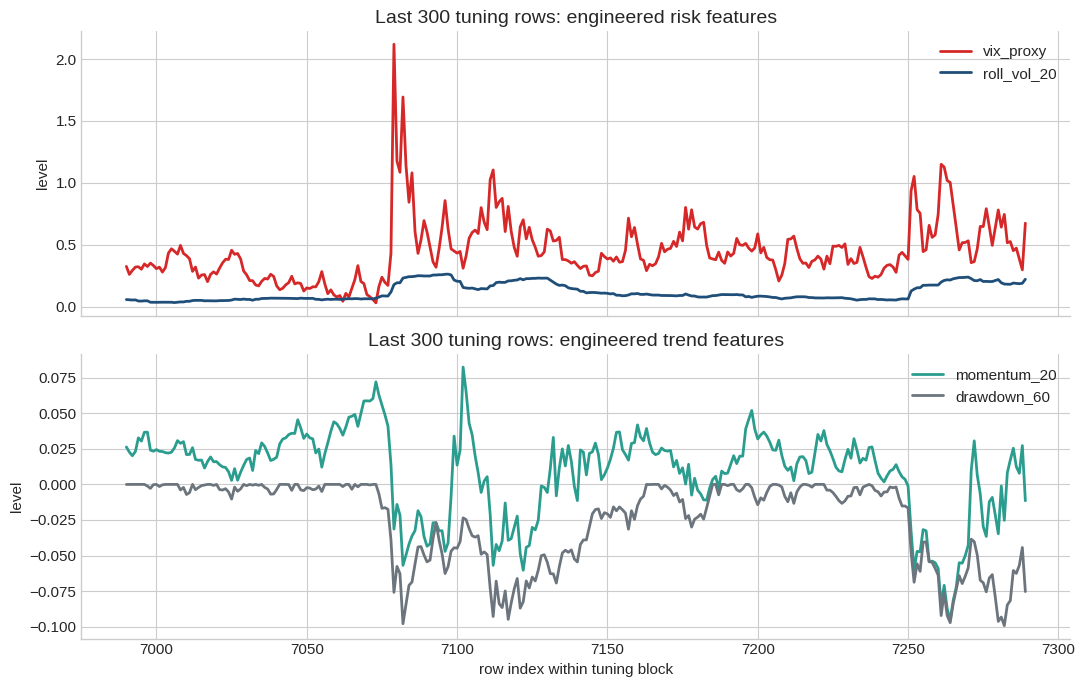

In [5]:
# 5. Inspect the engineered features with intermediate tables and diagnostic plots.
feature_preview_state = fit_feature_state(tune_df)
X_tune_preview = transform_features(tune_df, feature_preview_state, use_history=False)
X_holdout_preview = transform_features(holdout_df, feature_preview_state, use_history=True)

feature_summary = pd.Series(
    {
        "engineered_feature_count": int(X_tune_preview.shape[1]),
        "tuning_rows_after_feature_step": int(X_tune_preview.shape[0]),
        "holdout_rows_after_feature_step": int(X_holdout_preview.shape[0]),
        "missing_share_tuning": float(X_tune_preview.isna().mean().mean()),
        "mean_roll_vol_20": float(X_tune_preview.get("roll_vol_20", pd.Series(dtype=float)).mean()),
        "mean_momentum_20": float(X_tune_preview.get("momentum_20", pd.Series(dtype=float)).mean()),
    }
)

print("Feature summary")
display(feature_summary)
print("Preview of engineered features")
display(
    X_tune_preview[
        [c for c in ["lagged_forward_returns", "vix_proxy", "roll_vol_20", "momentum_20", "drawdown_60", "macro_sentiment_divergence"] if c in X_tune_preview.columns]
    ].head(10)
)

recent_feature_view = X_tune_preview[
    [c for c in ["vix_proxy", "roll_vol_20", "momentum_20", "drawdown_60"] if c in X_tune_preview.columns]
].tail(300).copy()
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
recent_feature_view[[c for c in ["vix_proxy", "roll_vol_20"] if c in recent_feature_view.columns]].plot(
    ax=axes[0],
    color=[COLORS["red"], COLORS["blue"]][: len([c for c in ["vix_proxy", "roll_vol_20"] if c in recent_feature_view.columns])],
    linewidth=2,
)
axes[0].set_title("Last 300 tuning rows: engineered risk features")
axes[0].set_ylabel("level")
recent_feature_view[[c for c in ["momentum_20", "drawdown_60"] if c in recent_feature_view.columns]].plot(
    ax=axes[1],
    color=[COLORS["teal"], COLORS["gray"]][: len([c for c in ["momentum_20", "drawdown_60"] if c in recent_feature_view.columns])],
    linewidth=2,
)
axes[1].set_title("Last 300 tuning rows: engineered trend features")
axes[1].set_ylabel("level")
axes[1].set_xlabel("row index within tuning block")
plt.tight_layout()
plt.show()


In [6]:
# 6. Fit the regime detector, fit the return model, and define the strategy sizing logic.
# Fit a Gaussian HMM regime model and label states using realized return behavior.
def fit_regime_detector(X: pd.DataFrame, returns: pd.Series | None = None, n_states: int = 3) -> dict:
    feature_columns = ["vix_proxy_pct", "roll_vol_20", "momentum_20", "autocorr_20"]

    regime_input = X[feature_columns].copy().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    scaler = StandardScaler()
    Z = scaler.fit_transform(regime_input)

    resolved_states = int(max(2, min(n_states, len(regime_input) // 200 if len(regime_input) > 400 else 2)))
    model = GaussianHMM(n_components=resolved_states, covariance_type="diag", n_iter=250, random_state=42)
    model.fit(Z)
    states = model.predict(Z)
    probs = model.predict_proba(Z)
    transition_matrix = model.transmat_

    if returns is None:
        state_labels = {s: f"state_{s}" for s in range(int(states.max()) + 1)}
    else:
        stats = (
            pd.DataFrame({"state": states, "ret": pd.Series(returns).reset_index(drop=True).astype(float)})
            .groupby("state")["ret"]
            .agg(["mean", "std", "count"])
            .rename(columns={"std": "vol"})
        )
        stats["vol"] = stats["vol"].fillna(0.0)
        best_ret_state = int(stats["mean"].idxmax())
        worst_ret_state = int(stats["mean"].idxmin())
        highest_vol_state = int(stats["vol"].idxmax())
        state_labels = {s: "normal" for s in range(int(states.max()) + 1)}
        if best_ret_state != highest_vol_state:
            state_labels[best_ret_state] = "bull_low_vol"
        state_labels[worst_ret_state] = "bear_high_vol"
        for s in state_labels:
            if s not in (best_ret_state, worst_ret_state):
                state_labels[s] = "transition"

    return {
        "feature_columns": feature_columns,
        "scaler": scaler,
        "model": model,
        "state_labels": state_labels,
        "transition_matrix": transition_matrix,
    }


# Predict regime states, probabilities, stability, and switch risk for a feature block.
def predict_regimes(X: pd.DataFrame, state: dict) -> pd.DataFrame:
    Z = X[state["feature_columns"]].copy().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    Z = state["scaler"].transform(Z)

    probs = state["model"].predict_proba(Z)
    states = state["model"].predict(Z)

    out = pd.DataFrame(index=X.index)
    out["regime_state"] = states
    for i in range(probs.shape[1]):
        out[f"regime_prob_{i}"] = probs[:, i]
    out["regime_stability"] = probs.max(axis=1)
    out["regime_switch_risk"] = 1.0 - np.array([state["transition_matrix"][s, s] for s in states], dtype=float)
    out["regime_label"] = [state["state_labels"].get(int(s), f"state_{int(s)}") for s in states]
    return out


# Fit point and quantile XGBoost models used for return prediction and confidence scoring.
def fit_return_model(X: pd.DataFrame, y: pd.Series) -> dict:
    X = X.copy().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y = pd.Series(y).astype(float)

    point_model = XGBRegressor(
        n_estimators=MODEL_PARAMS["n_estimators"],
        max_depth=MODEL_PARAMS["max_depth"],
        learning_rate=MODEL_PARAMS["learning_rate"],
        subsample=MODEL_PARAMS["subsample"],
        colsample_bytree=MODEL_PARAMS["colsample_bytree"],
        objective="reg:squarederror",
        tree_method="hist",
        seed=MODEL_PARAMS["random_state"],
        nthread=1,
    )
    lower_model = XGBRegressor(
        n_estimators=max(150, MODEL_PARAMS["n_estimators"] // 3),
        max_depth=MODEL_PARAMS["max_depth"],
        learning_rate=MODEL_PARAMS["learning_rate"],
        subsample=MODEL_PARAMS["subsample"],
        colsample_bytree=MODEL_PARAMS["colsample_bytree"],
        objective="reg:quantileerror",
        quantile_alpha=0.1,
        tree_method="hist",
        seed=MODEL_PARAMS["random_state"],
        nthread=1,
    )
    upper_model = XGBRegressor(
        n_estimators=max(150, MODEL_PARAMS["n_estimators"] // 3),
        max_depth=MODEL_PARAMS["max_depth"],
        learning_rate=MODEL_PARAMS["learning_rate"],
        subsample=MODEL_PARAMS["subsample"],
        colsample_bytree=MODEL_PARAMS["colsample_bytree"],
        objective="reg:quantileerror",
        quantile_alpha=0.9,
        tree_method="hist",
        seed=MODEL_PARAMS["random_state"],
        nthread=1,
    )

    point_model.fit(X, y)
    lower_model.fit(X, y)
    upper_model.fit(X, y)

    train_pred = point_model.predict(X)
    train_low = lower_model.predict(X)
    train_high = upper_model.predict(X)
    width = np.maximum(train_high - train_low, 1e-8)
    raw_conf = np.abs(train_pred) / width

    return {
        "feature_columns": X.columns.tolist(),
        "point_model": point_model,
        "lower_model": lower_model,
        "upper_model": upper_model,
        "confidence_low": float(np.quantile(raw_conf, 0.1)),
        "confidence_high": float(np.quantile(raw_conf, 0.9)),
    }


# Predict excess returns and scale interval width into a bounded confidence score.
def predict_return_model(X: pd.DataFrame, state: dict) -> pd.DataFrame:
    X = X.copy()
    X = X[state["feature_columns"]].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    point = state["point_model"].predict(X)
    lower = state["lower_model"].predict(X)
    upper = state["upper_model"].predict(X)
    width = np.maximum(upper - lower, 1e-8)
    raw_conf = np.abs(point) / width
    confidence = (raw_conf - state["confidence_low"]) / (state["confidence_high"] - state["confidence_low"] + 1e-8)
    confidence = np.clip(confidence, 0.0, 1.0)

    return pd.DataFrame(
        {
            "predicted_excess_return": point,
            "confidence": confidence,
        },
        index=X.index,
    )


# Compare realized strategy volatility with realized market volatility.
def volatility_ratio(strategy_returns: pd.Series, market_returns: pd.Series) -> float:
    std_s = float(strategy_returns.std(ddof=0))
    std_m = float(market_returns.std(ddof=0))
    return std_s / (std_m + 1e-8)


# Measure the annualized geometric return shortfall versus the market, floored at zero.
def return_gap(strategy_returns: list[float], market_returns: list[float]) -> float:
    s = np.array(strategy_returns, dtype=float)
    m = np.array(market_returns, dtype=float)
    strat_mean = np.prod(1.0 + s) ** (1.0 / len(s)) - 1.0
    mkt_mean = np.prod(1.0 + m) ** (1.0 / len(m)) - 1.0
    return max(0.0, (mkt_mean - strat_mean) * 252)


# Convert predictions, confidence, regimes, and realized risk controls into bounded weights.
def generate_weights(
    predicted_excess_return: pd.Series,
    confidence: pd.Series,
    strategy_params: dict,
    current_volatility: pd.Series,
    regime_label: pd.Series,
    forward_returns: pd.Series,
    risk_free_rate: pd.Series,
) -> pd.Series:
    pred = pd.Series(predicted_excess_return).astype(float).reset_index(drop=True)
    conf = pd.Series(confidence).astype(float).reset_index(drop=True)
    vol = pd.Series(current_volatility).astype(float).reset_index(drop=True)
    regimes = pd.Series(regime_label).astype(str).reset_index(drop=True)

    params = {**FIXED_STRATEGY_DEFAULTS, **strategy_params}
    weights = np.ones(len(pred), dtype=float)
    strat_returns = []
    mkt_returns = []

    for i in range(len(pred)):
        if conf.iloc[i] < params["confidence_threshold"]:
            weight = 1.0
        else:
            reg_mult = REGIME_MULTIPLIERS.get(regimes.iloc[i], 1.0)
            annual_vol = float(vol.iloc[i]) if np.isfinite(vol.iloc[i]) else params["target_annual_vol"]
            annual_vol = max(annual_vol, 1e-6)
            vol_scale = np.clip(
                params["target_annual_vol"] / annual_vol,
                params["vol_scale_min"],
                params["vol_scale_max"],
            )
            weight = 1.0 + params["gain"] * float(pred.iloc[i]) * vol_scale * reg_mult

        if i > 0:
            strat_hist = pd.Series(strat_returns[-params["vol_servo_window"] :], dtype=float)
            mkt_hist = pd.Series(mkt_returns[-params["vol_servo_window"] :], dtype=float)
            ratio = volatility_ratio(strat_hist, mkt_hist)
            if ratio > params["hard_vol_cap"]:
                weight = 1.0 + 0.20 * (weight - 1.0)
            elif ratio > params["soft_vol_cap"]:
                weight = 1.0 + 0.55 * (weight - 1.0)
            if return_gap(strat_returns, mkt_returns) > 0:
                weight = max(weight, 1.0)

        weight = float(np.clip(weight, params["min_weight"], params["max_weight"]))
        weights[i] = weight

        fwd = float(pd.Series(forward_returns).iloc[i])
        rf = float(pd.Series(risk_free_rate).iloc[i])
        excess_return = fwd - rf
        strat_returns.append(weight * excess_return + rf)
        mkt_returns.append(excess_return + rf)

    return pd.Series(weights, index=predicted_excess_return.index)


In [7]:
# 7. Build the inner walk-forward CV cache on the tuning block and define the CV evaluation function.
cv_fold_cache = []

for fold_number, (train_idx, val_idx) in enumerate(walk_forward_splits(len(tune_df), **cv_params), start=1):
    train_fold = tune_df.iloc[train_idx].copy()
    val_fold = tune_df.iloc[val_idx].copy()

    # 7.1 Fit the full fixed modeling pipeline on this fold once.
    feature_state = fit_feature_state(train_fold)
    X_train = transform_features(train_fold, feature_state, use_history=False)
    X_val = transform_features(val_fold, feature_state, use_history=True)

    regime_state = fit_regime_detector(X_train, returns=train_fold["forward_returns"], n_states=3)
    reg_train = predict_regimes(X_train, regime_state)
    reg_val = predict_regimes(X_val, regime_state)

    X_train_all = pd.concat([X_train, reg_train.drop(columns=["regime_label"])], axis=1)
    X_val_all = pd.concat([X_val, reg_val.drop(columns=["regime_label"])], axis=1)

    model_state = fit_return_model(X_train_all, train_fold["market_forward_excess_returns"])
    pred_val = predict_return_model(X_val_all, model_state)

    cv_fold_cache.append(
        {
            "fold": fold_number,
            "train_start": int(train_idx.min()),
            "train_end": int(train_idx.max()),
            "val_start": int(val_idx.min()),
            "val_end": int(val_idx.max()),
            "solution": val_fold[["risk_free_rate", "forward_returns"]].copy(),
            "predicted_excess_return": pred_val["predicted_excess_return"].copy(),
            "confidence": pred_val["confidence"].copy(),
            "current_volatility": X_val.get("roll_vol_20", pd.Series(np.nan, index=X_val.index)).copy(),
            "regime_label": reg_val["regime_label"].copy(),
        }
    )


# Score one strategy parameter set across cached CV folds and return fold diagnostics.
def evaluate_strategy_params(strategy_params: dict, fold_cache: list[dict]) -> tuple[float, pd.DataFrame]:
    fold_rows = []
    fold_scores = []
    for fold_payload in fold_cache:
        weights = generate_weights(
            predicted_excess_return=fold_payload["predicted_excess_return"],
            confidence=fold_payload["confidence"],
            strategy_params=strategy_params,
            current_volatility=fold_payload["current_volatility"],
            regime_label=fold_payload["regime_label"],
            forward_returns=fold_payload["solution"]["forward_returns"],
            risk_free_rate=fold_payload["solution"]["risk_free_rate"],
        )
        fold_score = score(
            fold_payload["solution"],
            pd.DataFrame({"prediction": weights.values}, index=fold_payload["solution"].index),
        )
        fold_scores.append(float(fold_score))
        fold_rows.append(
            {
                "fold": fold_payload["fold"],
                "train_start": fold_payload["train_start"],
                "train_end": fold_payload["train_end"],
                "val_start": fold_payload["val_start"],
                "val_end": fold_payload["val_end"],
                "adjusted_sharpe": float(fold_score),
                "mean_confidence": float(fold_payload["confidence"].mean()),
                "mean_weight": float(weights.mean()),
                "mean_roll_vol_20": float(fold_payload["current_volatility"].mean()),
                "dominant_regime": fold_payload["regime_label"].mode().iloc[0],
            }
        )
    return float(np.mean(fold_scores)), pd.DataFrame(fold_rows)

baseline_inner_cv_mean, baseline_cv_results = evaluate_strategy_params(INITIAL_STRATEGY_PARAMS, cv_fold_cache)
print(f"Cached CV folds built: {len(cv_fold_cache)}")
print(f"Initial untuned strategy mean CV adjusted Sharpe: {baseline_inner_cv_mean:.4f}")
display(baseline_cv_results)


Cached CV folds built: 6
Initial untuned strategy mean CV adjusted Sharpe: 0.7246


,fold,train_start,train_end,val_start,val_end,adjusted_sharpe,mean_confidence,mean_weight,mean_roll_vol_20,dominant_regime
0,1,0,3644,3790,4372,0.976980,0.350858,0.964844,0.097941,transition
1,2,0,4227,4373,4955,-0.435979,0.423197,1.076260,0.237727,transition
2,3,0,4810,4956,5538,0.641542,0.369652,1.012409,0.177386,bear_high_vol
3,4,0,5393,5539,6121,1.610602,0.322459,1.003750,0.113536,transition
4,5,0,5976,6122,6704,0.513374,0.533008,1.008364,0.126502,bear_high_vol
5,6,0,6559,6705,7287,1.040961,0.887947,0.919900,0.097888,transition


Best Optuna trial parameters


confidence_threshold      0.363733
gain                    179.320325
target_annual_vol         0.298329
soft_vol_cap              1.149479
min_weight                0.000000
max_weight                2.000000
vol_scale_min             0.500000
vol_scale_max             2.000000
vol_servo_window         60.000000
hard_vol_cap              1.200000
dtype: float64

Best inner CV mean adjusted Sharpe: 0.8526
Top trials


,number,mean_cv_adjusted_sharpe,params_confidence_threshold,params_gain,params_soft_vol_cap,params_target_annual_vol,state,best_so_far
12,12,0.852582,0.363733,179.320325,1.149479,0.298329,COMPLETE,0.852582
16,16,0.848065,0.360912,161.752793,1.199203,0.298248,COMPLETE,0.852582
21,21,0.844707,0.359024,161.139753,1.136887,0.299400,COMPLETE,0.852582
38,38,0.835483,0.373504,162.926585,1.143599,0.270771,COMPLETE,0.852582
25,25,0.833047,0.350165,136.314360,1.181092,0.277757,COMPLETE,0.852582
32,32,0.828679,0.417709,167.597209,1.185818,0.278671,COMPLETE,0.852582
11,11,0.827194,0.362772,165.226367,1.135585,0.291277,COMPLETE,0.827194
31,31,0.819814,0.359759,134.347669,1.182927,0.278375,COMPLETE,0.852582
35,35,0.810606,0.353334,128.539642,1.173502,0.241984,COMPLETE,0.852582
24,24,0.809756,0.451731,178.284084,1.149499,0.248024,COMPLETE,0.852582


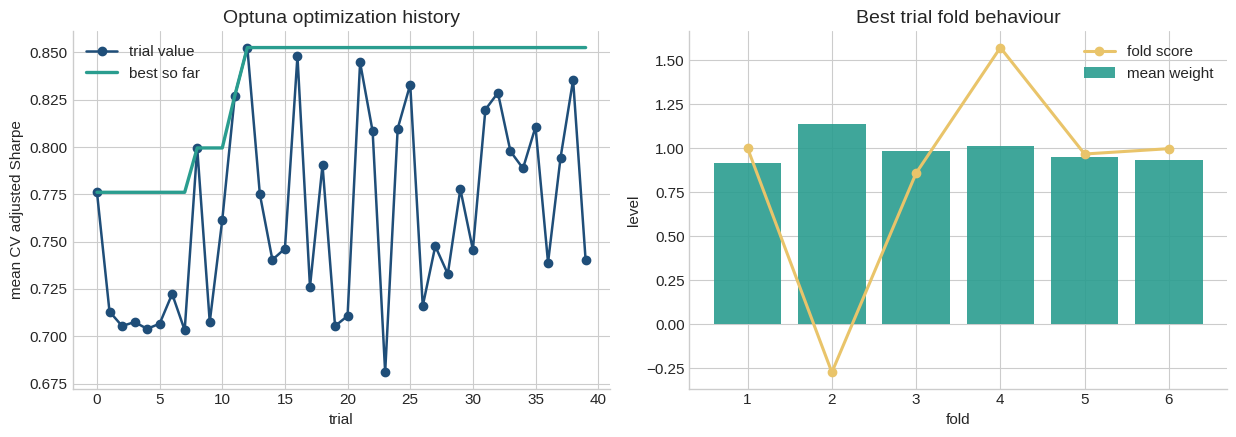

In [8]:
# 8. Run a narrow Optuna strategy-only search on the cached CV folds and inspect the study results.
# Sample strategy parameters for one Optuna trial and return its mean CV adjusted Sharpe.
def objective(trial: optuna.trial.Trial) -> float:
    strategy_params = {
        "confidence_threshold": trial.suggest_float("confidence_threshold", *SEARCH_SPACE["confidence_threshold"]),
        "gain": trial.suggest_float("gain", *SEARCH_SPACE["gain"]),
        "target_annual_vol": trial.suggest_float("target_annual_vol", *SEARCH_SPACE["target_annual_vol"]),
        "soft_vol_cap": trial.suggest_float("soft_vol_cap", *SEARCH_SPACE["soft_vol_cap"]),
        **FIXED_STRATEGY_DEFAULTS,
    }
    mean_score, _ = evaluate_strategy_params(strategy_params, cv_fold_cache)
    return mean_score

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

best_strategy_params = {**study.best_trial.params, **FIXED_STRATEGY_DEFAULTS}
best_inner_cv_mean_adjusted_sharpe, best_cv_results = evaluate_strategy_params(best_strategy_params, cv_fold_cache)

study_results = study.trials_dataframe(attrs=("number", "value", "params", "state")).rename(columns={"value": "mean_cv_adjusted_sharpe"})
study_results["best_so_far"] = study_results["mean_cv_adjusted_sharpe"].cummax()

print("Best Optuna trial parameters")
display(pd.Series(best_strategy_params))
print(f"Best inner CV mean adjusted Sharpe: {best_inner_cv_mean_adjusted_sharpe:.4f}")
print("Top trials")
display(study_results.sort_values("mean_cv_adjusted_sharpe", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].plot(study_results["number"], study_results["mean_cv_adjusted_sharpe"], marker="o", linewidth=1.8, color=COLORS["blue"], label="trial value")
axes[0].plot(study_results["number"], study_results["best_so_far"], linewidth=2.4, color=COLORS["teal"], label="best so far")
axes[0].set_title("Optuna optimization history")
axes[0].set_xlabel("trial")
axes[0].set_ylabel("mean CV adjusted Sharpe")
axes[0].legend()
axes[1].bar(best_cv_results["fold"], best_cv_results["mean_weight"], color=COLORS["teal"], alpha=0.9, label="mean weight")
axes[1].plot(best_cv_results["fold"], best_cv_results["adjusted_sharpe"], marker="o", linewidth=2.2, color=COLORS["gold"], label="fold score")
axes[1].set_title("Best trial fold behaviour")
axes[1].set_xlabel("fold")
axes[1].set_ylabel("level")
axes[1].legend()
plt.tight_layout()
plt.show()


In [9]:
# 9. Refit the fixed modeling pipeline on the full tuning block, evaluate once on the untouched holdout, and build performance series.
# 9.1 Fit the full fixed modeling pipeline on all tuning rows.
feature_state = fit_feature_state(tune_df)
X_tune = transform_features(tune_df, feature_state, use_history=False)
X_holdout = transform_features(holdout_df, feature_state, use_history=True)

regime_state = fit_regime_detector(X_tune, returns=tune_df["forward_returns"], n_states=3)
reg_tune = predict_regimes(X_tune, regime_state)
reg_holdout = predict_regimes(X_holdout, regime_state)

X_tune_all = pd.concat([X_tune, reg_tune.drop(columns=["regime_label"])], axis=1)
X_holdout_all = pd.concat([X_holdout, reg_holdout.drop(columns=["regime_label"])], axis=1)

model_state = fit_return_model(X_tune_all, tune_df["market_forward_excess_returns"])
pred_holdout = predict_return_model(X_holdout_all, model_state)

# 9.2 Apply the best CV-selected strategy parameters to the untouched holdout.
holdout_weights = generate_weights(
    predicted_excess_return=pred_holdout["predicted_excess_return"],
    confidence=pred_holdout["confidence"],
    strategy_params=best_strategy_params,
    current_volatility=X_holdout.get("roll_vol_20", pd.Series(np.nan, index=X_holdout.index)),
    regime_label=reg_holdout["regime_label"],
    forward_returns=holdout_df["forward_returns"],
    risk_free_rate=holdout_df["risk_free_rate"],
)
baseline_weights = pd.Series(1.0, index=holdout_df.index)

holdout_solution = holdout_df[["risk_free_rate", "forward_returns"]].copy()
final_holdout_adjusted_sharpe = score(
    holdout_solution,
    pd.DataFrame({"prediction": holdout_weights.values}, index=holdout_df.index),
)
final_holdout_adjusted_sharpe_baseline = score(
    holdout_solution,
    pd.DataFrame({"prediction": baseline_weights.values}, index=holdout_df.index),
)

holdout_results = holdout_df[["date_id", "forward_returns", "risk_free_rate"]].copy()
holdout_results["prediction"] = holdout_weights.values
holdout_results["confidence"] = pred_holdout["confidence"].values
holdout_results["predicted_excess_return"] = pred_holdout["predicted_excess_return"].values
holdout_results["regime_label"] = reg_holdout["regime_label"].values
holdout_results["strategy_returns"] = (
    holdout_results["risk_free_rate"] * (1 - holdout_results["prediction"]) + holdout_results["prediction"] * holdout_results["forward_returns"]
)
holdout_results["baseline_returns"] = holdout_results["forward_returns"]
holdout_results["strategy_cumulative"] = (1 + holdout_results["strategy_returns"]).cumprod()
holdout_results["baseline_cumulative"] = (1 + holdout_results["baseline_returns"]).cumprod()


Selected strategy parameters from Optuna


confidence_threshold      0.363733
gain                    179.320325
target_annual_vol         0.298329
soft_vol_cap              1.149479
min_weight                0.000000
max_weight                2.000000
vol_scale_min             0.500000
vol_scale_max             2.000000
vol_servo_window         60.000000
hard_vol_cap              1.200000
dtype: float64


Initial untuned strategy mean CV adjusted Sharpe: 0.7246
Best inner CV mean adjusted Sharpe: 0.8526
Final holdout adjusted Sharpe (model): 0.8605
Final holdout adjusted Sharpe (baseline w=1): 0.7151

Best-CV fold diagnostics


,fold,train_start,train_end,val_start,val_end,adjusted_sharpe,mean_confidence,mean_weight,mean_roll_vol_20,dominant_regime
0,1,0,3644,3790,4372,0.998524,0.350858,0.913950,0.097941,transition
1,2,0,4227,4373,4955,-0.274084,0.423197,1.135643,0.237727,transition
2,3,0,4810,4956,5538,0.857809,0.369652,0.980680,0.177386,bear_high_vol
3,4,0,5393,5539,6121,1.570676,0.322459,1.012414,0.113536,transition
4,5,0,5976,6122,6704,0.966058,0.533008,0.949712,0.126502,bear_high_vol
5,6,0,6559,6705,7287,0.996510,0.887947,0.930480,0.097888,transition



Holdout predictions preview


,date_id,prediction,confidence,predicted_excess_return,regime_label
7490,7490,1.000000,0.172498,0.001022,transition
7491,7491,1.000000,0.127569,0.000945,bull_low_vol
7492,7492,1.459473,0.540532,0.003621,bear_high_vol
7493,7493,1.823903,0.739317,0.004505,bull_low_vol
7494,7494,1.161733,0.924707,0.006040,bear_high_vol
7495,7495,1.386221,0.828207,0.005664,bull_low_vol
7496,7496,1.483112,1.000000,0.019123,bear_high_vol
7497,7497,1.522730,1.000000,0.007901,bull_low_vol
7498,7498,1.187570,1.000000,0.007591,bear_high_vol
7499,7499,1.550310,1.000000,0.008252,bull_low_vol


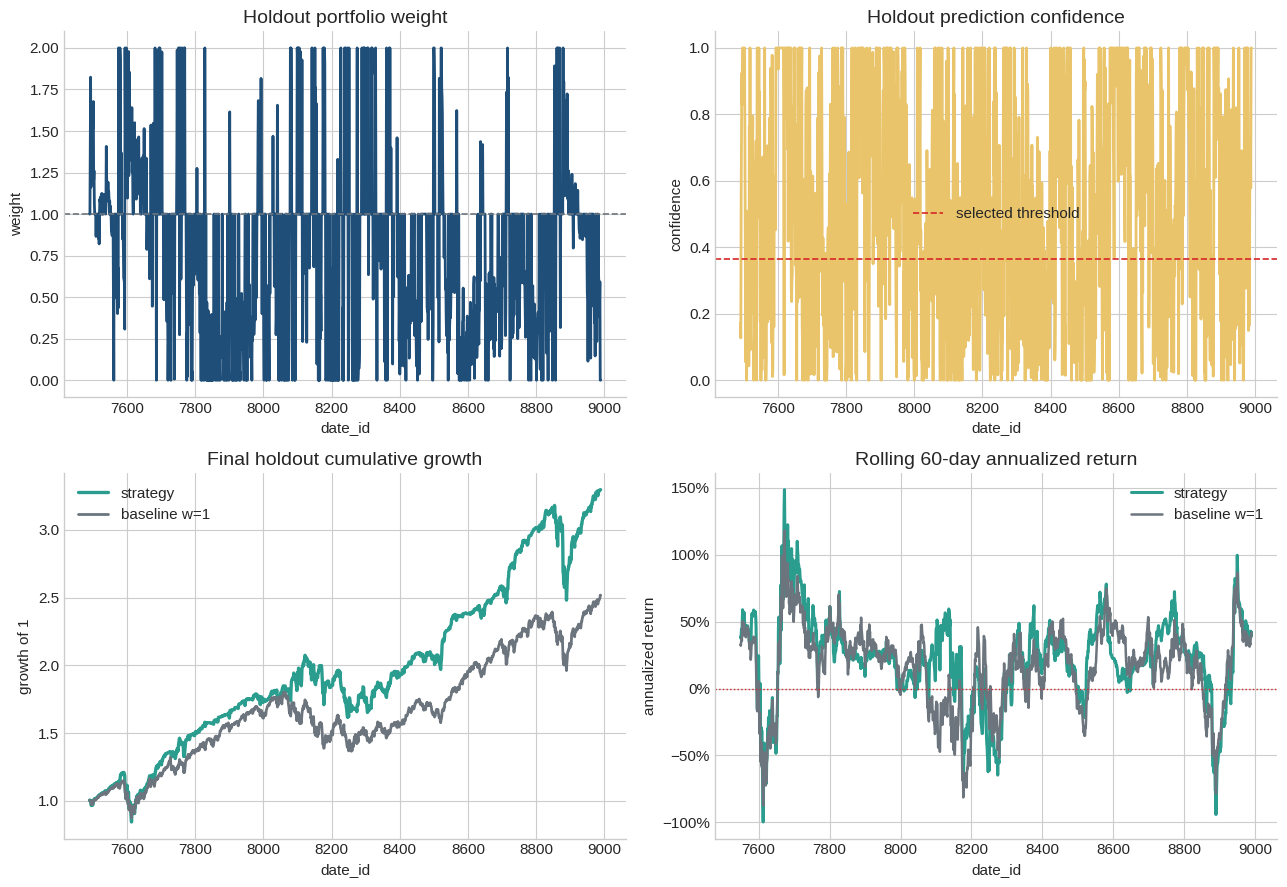

In [10]:
# 10. Report the selected strategy parameters, the best inner CV score, the final holdout score, and the holdout plots.
print("Selected strategy parameters from Optuna")
display(pd.Series(best_strategy_params))
print(f"\nInitial untuned strategy mean CV adjusted Sharpe: {baseline_inner_cv_mean:.4f}")
print(f"Best inner CV mean adjusted Sharpe: {best_inner_cv_mean_adjusted_sharpe:.4f}")
print(f"Final holdout adjusted Sharpe (model): {final_holdout_adjusted_sharpe:.4f}")
print(f"Final holdout adjusted Sharpe (baseline w=1): {final_holdout_adjusted_sharpe_baseline:.4f}")
print("\nBest-CV fold diagnostics")
display(best_cv_results)
print("\nHoldout predictions preview")
display(holdout_results[["date_id", "prediction", "confidence", "predicted_excess_return", "regime_label"]].head(10))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(holdout_results["date_id"], holdout_results["prediction"], color=COLORS["blue"], linewidth=2)
axes[0, 0].axhline(1.0, color=COLORS["gray"], linestyle="--", linewidth=1.2)
axes[0, 0].set_title("Holdout portfolio weight")
axes[0, 0].set_xlabel("date_id")
axes[0, 0].set_ylabel("weight")

axes[0, 1].plot(holdout_results["date_id"], holdout_results["confidence"], color=COLORS["gold"], linewidth=2)
axes[0, 1].axhline(best_strategy_params["confidence_threshold"], color=COLORS["red"], linestyle="--", linewidth=1.2, label="selected threshold")
axes[0, 1].set_title("Holdout prediction confidence")
axes[0, 1].set_xlabel("date_id")
axes[0, 1].set_ylabel("confidence")
axes[0, 1].legend()

axes[1, 0].plot(holdout_results["date_id"], holdout_results["strategy_cumulative"], color=COLORS["teal"], linewidth=2.4, label="strategy")
axes[1, 0].plot(holdout_results["date_id"], holdout_results["baseline_cumulative"], color=COLORS["gray"], linewidth=2.0, label="baseline w=1")
axes[1, 0].set_title("Final holdout cumulative growth")
axes[1, 0].set_xlabel("date_id")
axes[1, 0].set_ylabel("growth of 1")
axes[1, 0].legend()

rolling_window = 60
rolling_strategy = holdout_results["strategy_returns"].rolling(rolling_window).mean() * 252
rolling_baseline = holdout_results["baseline_returns"].rolling(rolling_window).mean() * 252
axes[1, 1].plot(holdout_results["date_id"], rolling_strategy, color=COLORS["teal"], linewidth=2.2, label="strategy")
axes[1, 1].plot(holdout_results["date_id"], rolling_baseline, color=COLORS["gray"], linewidth=1.8, label="baseline w=1")
axes[1, 1].axhline(0.0, color=COLORS["red"], linestyle=":", linewidth=1)
axes[1, 1].set_title(f"Rolling {rolling_window}-day annualized return")
axes[1, 1].set_xlabel("date_id")
axes[1, 1].set_ylabel("annualized return")
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1, 1].legend()
plt.tight_layout()
plt.show()


## Interpretation

The Optuna search used only the inner walk-forward CV folds built from the tuning block. The best inner CV score shows how the selected strategy parameters performed across several historical validation windows before the final holdout evaluation.

The final holdout score is evaluated once after parameter selection and is the notebook's held-out offline estimate. The model's holdout adjusted Sharpe of 0.8605 is above the baseline weight-1 score of 0.7151, so the adaptive weighting adds value in this split without using the excluded Kaggle test file.

The fold diagnostics show that performance varies across time: some validation windows benefit more from the adaptive weights than others. The mean-weight bars are close to 1.0 in most folds, so the strategy usually stays near market exposure and changes exposure only moderately.
